Sử dụng thuật toán SOLOMON để chia training set và test set

In [1]:
import numpy as np
from solomon import solomon_split
from kfold import kfold_linear_1d, kfold_linear_2d, kfold_linear_3d, kfold_linear_4d, kfold_linear_8d  # từ kfold.py đã tạo

# --- DỮ LIỆU CỦA BẠN ---
x_train = np.array([
    3,4, 5, 6, 7, 8, 9, 10,
    15, 20, 25, 30, 35, 40, 45, 50,
    55, 60, 65, 70, 75, 80, 85, 90, 95, 100,
    110, 120, 130, 140, 150, 160, 170, 180, 190, 200,
    210, 220, 230, 240, 250, 260, 270, 280, 290, 300,
    310, 320, 330, 340, 350, 360, 370, 380
], dtype=float)

y_train = np.array([
    2.9620, 3.8648, 4.8237, 6.1511, 7.005, 8.515, 9.4552, 10.4988,
    14.9004, 20.2482, 24.5709, 29.7015, 33.941, 38.9905, 43.6784, 48.0311,
    52.7, 57.8442, 62.5892, 67.4436, 72.0883, 76.8276, 81.8644, 86.3656,
    91.2202, 96.3647, 105.961, 115.7981, 125.2903, 135.1993, 145.44,
    155.3276, 165.2622, 174.5583, 184.5487, 194.3147, 204.2765,
    213.7839, 223.7707, 233.5522, 244.2693, 253.7179, 264.0291,
    273.6122, 282.6807, 293.3765, 301.8912, 313.2924, 321.2665,
    331.5217, 341.7111, 350.8723, 361.4075, 371.5148
], dtype=float)


In [2]:
X = np.column_stack([x_train, y_train])

split = solomon_split(X, test_ratio=0.2, seed=42, max_iter=2000)
train_idx, test_idx = split["idx_A"], split["idx_B"]   # idx_B có kích thước ≈ 20%

x_tr, y_tr = x_train[train_idx], y_train[train_idx]
x_te, y_te = x_train[test_idx], y_train[test_idx]

print("SOLOMON diagnostics:",
      {k: split[k] for k in ["corr_frobenius","kmo_A","kmo_B","S_A","S_B"]})
print("Training set x: ",x_tr)
print("Training set y: ",y_tr)
print("Test set x: ",x_te)
print("Test set y: ", y_te)


SOLOMON diagnostics: {'corr_frobenius': 4.5951860953254924e-06, 'kmo_A': 0.5, 'kmo_B': 0.5, 'S_A': 14025.063254934252, 'S_B': 14023.503904308684}
Training set x:  [  3.   5.   7.   9.  10.  20.  25.  35.  40.  45.  55.  60.  65.  70.
  75.  80.  90.  95. 100. 110. 120. 130. 140. 150. 160. 170. 190. 200.
 210. 220. 230. 250. 260. 280. 290. 300. 310. 330. 340. 350. 360. 370.
 380.]
Training set y:  [  2.962    4.8237   7.005    9.4552  10.4988  20.2482  24.5709  33.941
  38.9905  43.6784  52.7     57.8442  62.5892  67.4436  72.0883  76.8276
  86.3656  91.2202  96.3647 105.961  115.7981 125.2903 135.1993 145.44
 155.3276 165.2622 184.5487 194.3147 204.2765 213.7839 223.7707 244.2693
 253.7179 273.6122 282.6807 293.3765 301.8912 321.2665 331.5217 341.7111
 350.8723 361.4075 371.5148]
Test set x:  [  4.   6.   8.  15.  30.  50.  85. 180. 240. 270. 320.]
Test set y:  [  3.8648   6.1511   8.515   14.9004  29.7015  48.0311  81.8644 174.5583
 233.5522 264.0291 313.2924]


## 1. Kiểm tra MAE, MSE, R2 khi dùng hàm số bậc nhất


===== Fold 1 =====
x_tr: [ 90.  20. 130. 290. 350. 230. 150. 190. 120. 330.  55.   9. 340. 250.
  95. 170.  25.  80.  60. 220.  45. 300. 140. 110.   3.  65.  75. 370.
   7. 310. 280.   5.  70.  40.]
y_tr: [ 86.3656  20.2482 125.2903 282.6807 341.7111 223.7707 145.44   184.5487
 115.7981 321.2665  52.7      9.4552 331.5217 244.2693  91.2202 165.2622
  24.5709  76.8276  57.8442 213.7839  43.6784 293.3765 135.1993 105.961
   2.962   62.5892  72.0883 361.4075   7.005  301.8912 273.6122   4.8237
  67.4436  38.9905]
Iteration    0: Cost 6.24e+03  dj_dw: -1.129e+02, dj_db:  1.672e-14   w:  1.129e+00, b:-1.67187e-16
Iteration 1000: Cost 2.30e-01  dj_dw: -4.872e-03, dj_db:  1.019e-15   w:  1.129e+02, b:-2.75389e-14
Iteration 2000: Cost 2.29e-01  dj_dw: -2.103e-07, dj_db: -3.265e-16   w:  1.129e+02, b:-3.01860e-14
Iteration 3000: Cost 2.29e-01  dj_dw: -9.074e-12, dj_db:  1.959e-16   w:  1.129e+02, b:-3.02933e-14
Iteration 4000: Cost 2.29e-01  dj_dw: -7.070e-13, dj_db: -5.225e-17   w:  1.129e+02

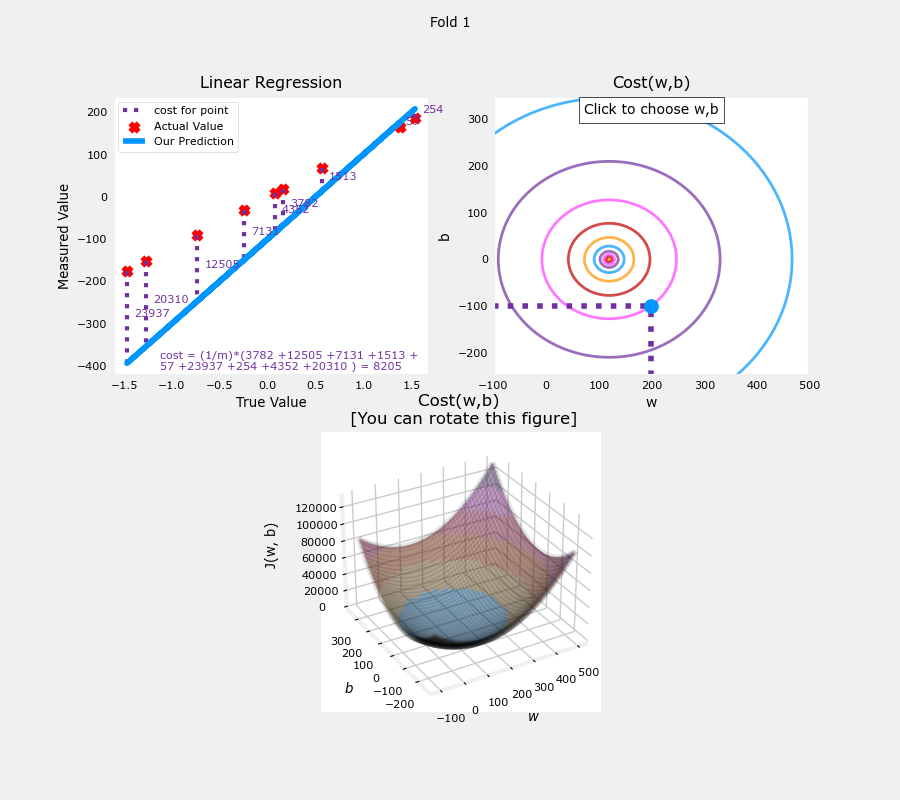


===== Fold 2 =====
x_tr: [210. 100. 160. 260. 360.  10. 380. 200.  35. 330.  55.   9. 340. 250.
  95. 170.  25.  80.  60. 220.  45. 300. 140. 110.   3.  65.  75. 370.
   7. 310. 280.   5.  70.  40.]
y_tr: [204.2765  96.3647 155.3276 253.7179 350.8723  10.4988 371.5148 194.3147
  33.941  321.2665  52.7      9.4552 331.5217 244.2693  91.2202 165.2622
  24.5709  76.8276  57.8442 213.7839  43.6784 293.3765 135.1993 105.961
   2.962   62.5892  72.0883 361.4075   7.005  301.8912 273.6122   4.8237
  67.4436  38.9905]
Iteration    0: Cost 7.08e+03  dj_dw: -1.202e+02, dj_db: -1.170e-14   w:  1.202e+00, b: 1.17031e-16
Iteration 1000: Cost 2.09e-01  dj_dw: -5.191e-03, dj_db: -5.407e-15   w:  1.202e+02, b: 1.42479e-14
Iteration 2000: Cost 2.09e-01  dj_dw: -2.241e-07, dj_db: -5.982e-15   w:  1.202e+02, b: 1.42670e-14
Iteration 3000: Cost 2.09e-01  dj_dw: -9.701e-12, dj_db: -5.329e-15   w:  1.202e+02, b: 1.42553e-14
Iteration 4000: Cost 2.09e-01  dj_dw: -7.019e-13, dj_db:  4.624e-15   w:  1.202e+02

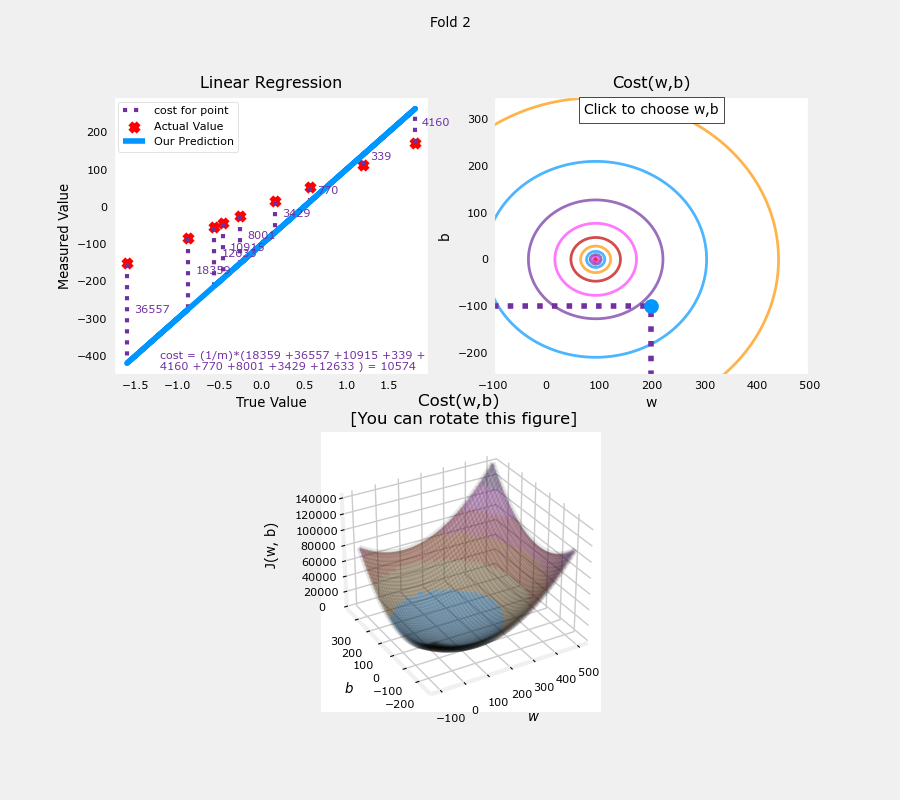


===== Fold 3 =====
x_tr: [210. 100. 160. 260. 360.  10. 380. 200.  35.  90.  20. 130. 290. 350.
 230. 150. 190. 120.  60. 220.  45. 300. 140. 110.   3.  65.  75. 370.
   7. 310. 280.   5.  70.  40.]
y_tr: [204.2765  96.3647 155.3276 253.7179 350.8723  10.4988 371.5148 194.3147
  33.941   86.3656  20.2482 125.2903 282.6807 341.7111 223.7707 145.44
 184.5487 115.7981  57.8442 213.7839  43.6784 293.3765 135.1993 105.961
   2.962   62.5892  72.0883 361.4075   7.005  301.8912 273.6122   4.8237
  67.4436  38.9905]
Iteration    0: Cost 6.48e+03  dj_dw: -1.150e+02, dj_db: -6.687e-15   w:  1.150e+00, b: 6.68746e-17
Iteration 1000: Cost 2.20e-01  dj_dw: -4.965e-03, dj_db: -1.176e-15   w:  1.150e+02, b: 7.10164e-15
Iteration 2000: Cost 2.20e-01  dj_dw: -2.143e-07, dj_db: -1.254e-15   w:  1.150e+02, b: 7.09811e-15
Iteration 3000: Cost 2.20e-01  dj_dw: -9.230e-12, dj_db:  1.502e-15   w:  1.150e+02, b: 7.09080e-15
Iteration 4000: Cost 2.20e-01  dj_dw: -7.014e-13, dj_db: -7.967e-16   w:  1.150e+02, 

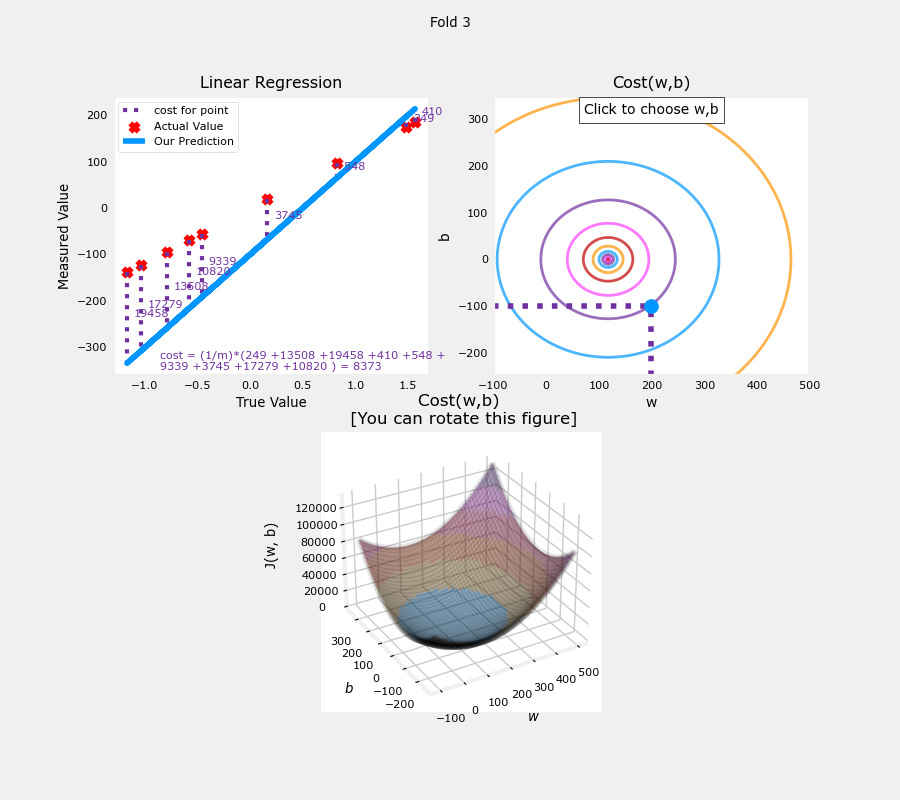


===== Fold 4 =====
x_tr: [210. 100. 160. 260. 360.  10. 380. 200.  35.  90.  20. 130. 290. 350.
 230. 150. 190. 120. 330.  55.   9. 340. 250.  95. 170.  25.  80.  75.
 370.   7. 310. 280.   5.  70.  40.]
y_tr: [204.2765  96.3647 155.3276 253.7179 350.8723  10.4988 371.5148 194.3147
  33.941   86.3656  20.2482 125.2903 282.6807 341.7111 223.7707 145.44
 184.5487 115.7981 321.2665  52.7      9.4552 331.5217 244.2693  91.2202
 165.2622  24.5709  76.8276  72.0883 361.4075   7.005  301.8912 273.6122
   4.8237  67.4436  38.9905]
Iteration    0: Cost 6.93e+03  dj_dw: -1.189e+02, dj_db:  8.120e-15   w:  1.189e+00, b:-8.12049e-17
Iteration 1000: Cost 2.28e-01  dj_dw: -5.135e-03, dj_db: -5.151e-15   w:  1.189e+02, b:-1.41720e-14
Iteration 2000: Cost 2.28e-01  dj_dw: -2.217e-07, dj_db: -4.796e-15   w:  1.189e+02, b:-1.41664e-14
Iteration 3000: Cost 2.28e-01  dj_dw: -9.592e-12, dj_db:  7.816e-15   w:  1.189e+02, b:-1.42715e-14
Iteration 4000: Cost 2.28e-01  dj_dw: -6.931e-13, dj_db:  5.634e-15   

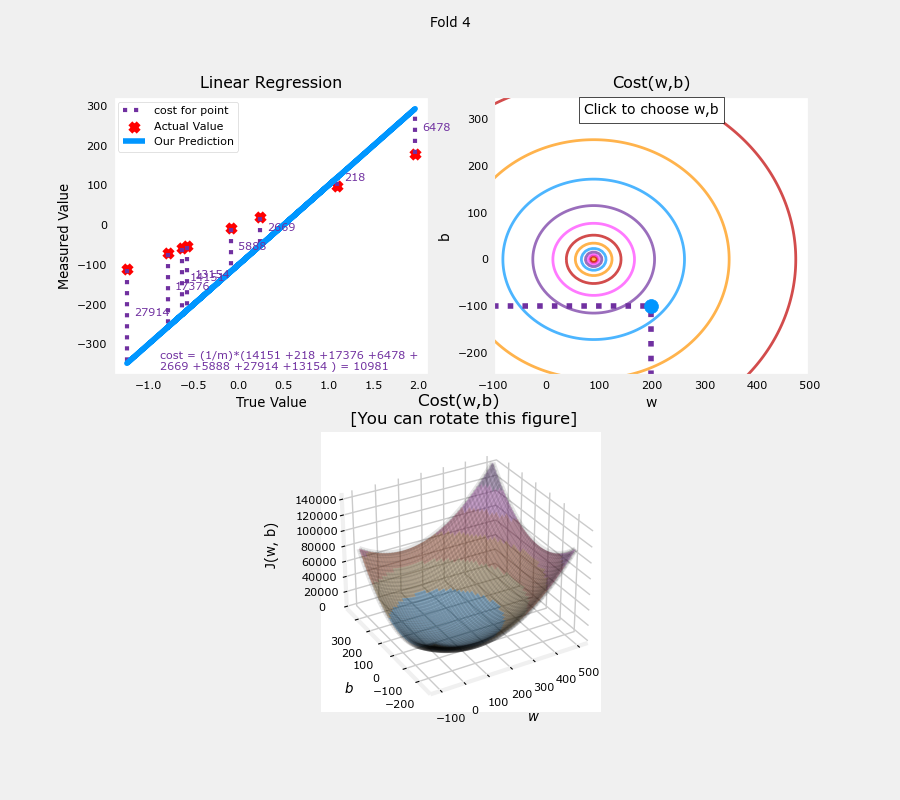


===== Fold 5 =====
x_tr: [210. 100. 160. 260. 360.  10. 380. 200.  35.  90.  20. 130. 290. 350.
 230. 150. 190. 120. 330.  55.   9. 340. 250.  95. 170.  25.  80.  60.
 220.  45. 300. 140. 110.   3.  65.]
y_tr: [204.2765  96.3647 155.3276 253.7179 350.8723  10.4988 371.5148 194.3147
  33.941   86.3656  20.2482 125.2903 282.6807 341.7111 223.7707 145.44
 184.5487 115.7981 321.2665  52.7      9.4552 331.5217 244.2693  91.2202
 165.2622  24.5709  76.8276  57.8442 213.7839  43.6784 293.3765 135.1993
 105.961    2.962   62.5892]
Iteration    0: Cost 5.95e+03  dj_dw: -1.102e+02, dj_db:  5.360e-14   w:  1.102e+00, b:-5.35952e-16
Iteration 1000: Cost 2.40e-01  dj_dw: -4.755e-03, dj_db: -9.516e-16   w:  1.101e+02, b:-4.61777e-14
Iteration 2000: Cost 2.40e-01  dj_dw: -2.053e-07, dj_db: -2.474e-15   w:  1.102e+02, b:-4.61652e-14
Iteration 3000: Cost 2.40e-01  dj_dw: -8.872e-12, dj_db:  5.456e-16   w:  1.102e+02, b:-4.61954e-14
Iteration 4000: Cost 2.40e-01  dj_dw: -7.009e-13, dj_db: -1.142e-16   

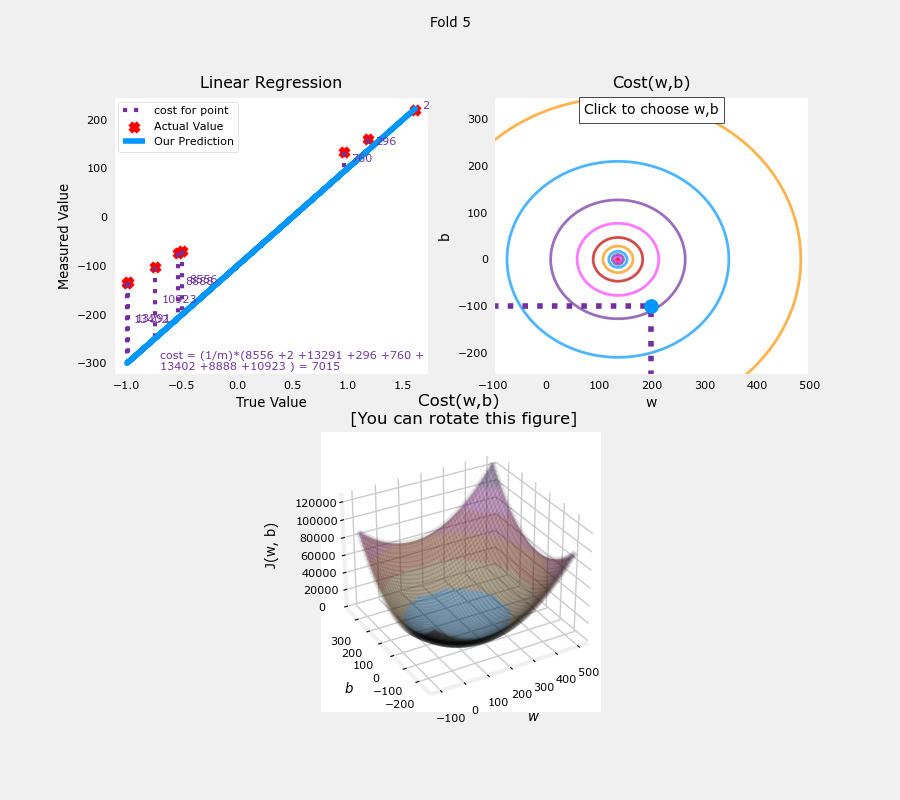

{'folds': [{'fold': 1, 'w': np.float64(0.9765488813605364), 'b': np.float64(-0.6052376457451487), 'MSE': np.float64(0.4368117104711848), 'MAE': np.float64(0.5356473804044403), 'R2': np.float64(0.9999696387417408), 'x_val': array([210., 100., 160., 260., 360.,  10., 380., 200.,  35.]), 'y_val': array([204.2765,  96.3647, 155.3276, 253.7179, 350.8723,  10.4988,
       371.5148, 194.3147,  33.941 ])}, {'fold': 2, 'w': np.float64(0.9765866581714338), 'b': np.float64(-0.5117069437688713), 'MSE': np.float64(0.6068123333667388), 'MAE': np.float64(0.6748435070495269), 'R2': np.float64(0.9999319403400495), 'x_val': array([ 90.,  20., 130., 290., 350., 230., 150., 190., 120.]), 'y_val': array([ 86.3656,  20.2482, 125.2903, 282.6807, 341.7111, 223.7707,
       145.44  , 184.5487, 115.7981])}, {'fold': 3, 'w': np.float64(0.9768521146246862), 'b': np.float64(-0.6179540368804624), 'MSE': np.float64(0.503919219909042), 'MAE': np.float64(0.6076633459262469), 'R2': np.float64(0.9999637304430892), 'x_va

In [3]:
%matplotlib widget
result = kfold_linear_1d(
    x_tr, y_tr,
    k=5,
    verbose=True,
    interactive=True,
    save_dir="fold_plots"   # tùy chọn
)
print(result)

Hàm bậc cao

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from multi_polynomial import zscore_normalize_features, run_gradient_descent_feng
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays


===== Fold 1 =====
x_tr: [ 90.  20. 130. 290. 350. 230. 150. 190. 120. 330.  55.   9. 340. 250.
  95. 170.  25.  80.  60. 220.  45. 300. 140. 110.   3.  65.  75. 370.
   7. 310. 280.   5.  70.  40.]
y_tr: [ 86.37  20.25 125.29 282.68 341.71 223.77 145.44 184.55 115.8  321.27
  52.7    9.46 331.52 244.27  91.22 165.26  24.57  76.83  57.84 213.78
  43.68 293.38 135.2  105.96   2.96  62.59  72.09 361.41   7.   301.89
 273.61   4.82  67.44  38.99]


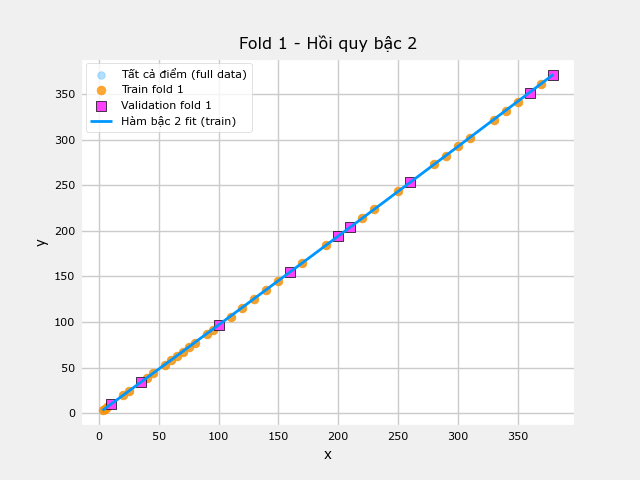

Coefficients: [9.61e-01 4.42e-05]
Intercept: 0.14500965353886386
Hàm hồi quy: y = 0.145 + 0.961*x + 0.000*x²
Fold 1 | MSE=0.266547 | MAE=0.434280 | R2=0.999981

===== Fold 2 =====
x_tr: [210. 100. 160. 260. 360.  10. 380. 200.  35. 330.  55.   9. 340. 250.
  95. 170.  25.  80.  60. 220.  45. 300. 140. 110.   3.  65.  75. 370.
   7. 310. 280.   5.  70.  40.]
y_tr: [204.28  96.36 155.33 253.72 350.87  10.5  371.51 194.31  33.94 321.27
  52.7    9.46 331.52 244.27  91.22 165.26  24.57  76.83  57.84 213.78
  43.68 293.38 135.2  105.96   2.96  62.59  72.09 361.41   7.   301.89
 273.61   4.82  67.44  38.99]


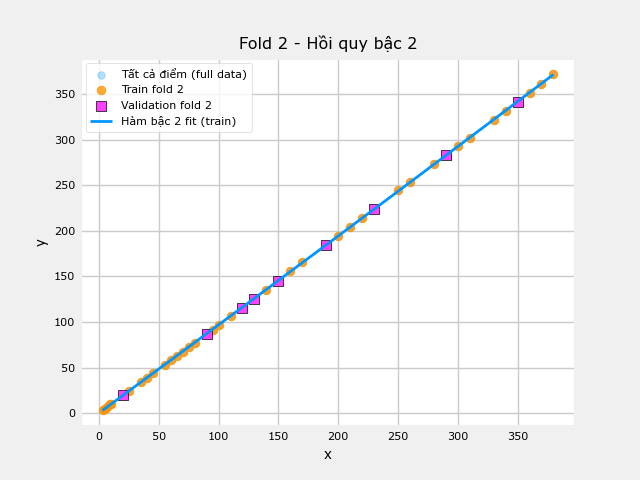

Coefficients: [9.64e-01 3.56e-05]
Intercept: 0.08502349622824568
Hàm hồi quy: y = 0.085 + 0.964*x + 0.000*x²
Fold 2 | MSE=0.223881 | MAE=0.346987 | R2=0.999975

===== Fold 3 =====
x_tr: [210. 100. 160. 260. 360.  10. 380. 200.  35.  90.  20. 130. 290. 350.
 230. 150. 190. 120.  60. 220.  45. 300. 140. 110.   3.  65.  75. 370.
   7. 310. 280.   5.  70.  40.]
y_tr: [204.28  96.36 155.33 253.72 350.87  10.5  371.51 194.31  33.94  86.37
  20.25 125.29 282.68 341.71 223.77 145.44 184.55 115.8   57.84 213.78
  43.68 293.38 135.2  105.96   2.96  62.59  72.09 361.41   7.   301.89
 273.61   4.82  67.44  38.99]


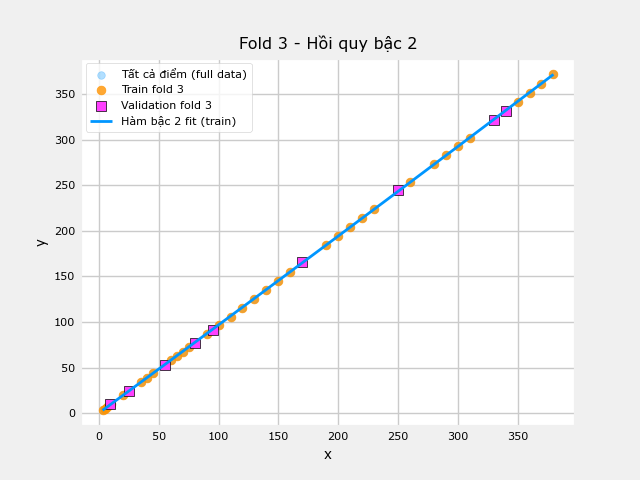

Coefficients: [9.62e-01 4.10e-05]
Intercept: 0.1510599817858349
Hàm hồi quy: y = 0.151 + 0.962*x + 0.000*x²
Fold 3 | MSE=0.403303 | MAE=0.596872 | R2=0.999971

===== Fold 4 =====
x_tr: [210. 100. 160. 260. 360.  10. 380. 200.  35.  90.  20. 130. 290. 350.
 230. 150. 190. 120. 330.  55.   9. 340. 250.  95. 170.  25.  80.  75.
 370.   7. 310. 280.   5.  70.  40.]
y_tr: [204.28  96.36 155.33 253.72 350.87  10.5  371.51 194.31  33.94  86.37
  20.25 125.29 282.68 341.71 223.77 145.44 184.55 115.8  321.27  52.7
   9.46 331.52 244.27  91.22 165.26  24.57  76.83  72.09 361.41   7.
 301.89 273.61   4.82  67.44  38.99]


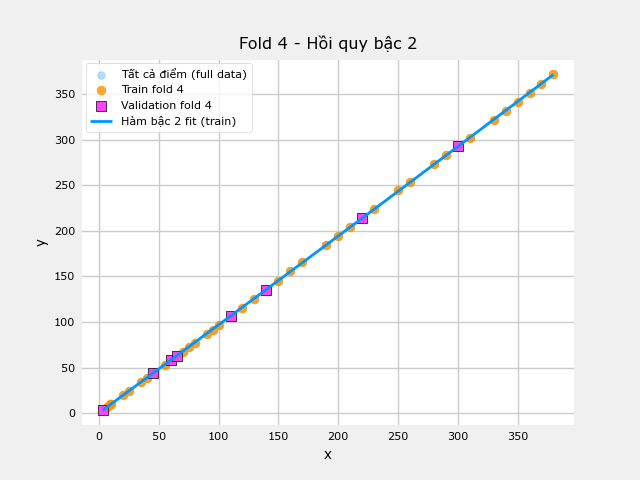

Coefficients: [9.62e-01 3.82e-05]
Intercept: 0.19466726863191752
Hàm hồi quy: y = 0.195 + 0.962*x + 0.000*x²
Fold 4 | MSE=0.224345 | MAE=0.357742 | R2=0.999973

===== Fold 5 =====
x_tr: [210. 100. 160. 260. 360.  10. 380. 200.  35.  90.  20. 130. 290. 350.
 230. 150. 190. 120. 330.  55.   9. 340. 250.  95. 170.  25.  80.  60.
 220.  45. 300. 140. 110.   3.  65.]
y_tr: [204.28  96.36 155.33 253.72 350.87  10.5  371.51 194.31  33.94  86.37
  20.25 125.29 282.68 341.71 223.77 145.44 184.55 115.8  321.27  52.7
   9.46 331.52 244.27  91.22 165.26  24.57  76.83  57.84 213.78  43.68
 293.38 135.2  105.96   2.96  62.59]


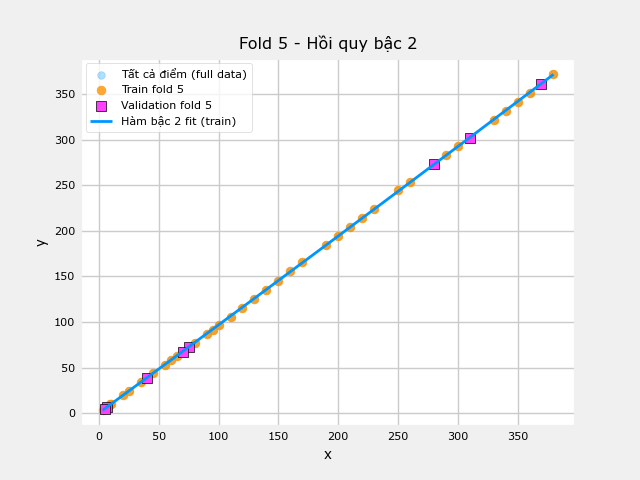

Coefficients: [9.62e-01 4.11e-05]
Intercept: 0.1930062478344894
Hàm hồi quy: y = 0.193 + 0.962*x + 0.000*x²
Fold 5 | MSE=0.181441 | MAE=0.341580 | R2=0.999990
{'folds': [{'fold': 1, 'w': np.float64(0.9609567609080003), 'w2': np.float64(4.4150260655442044e-05), 'b': np.float64(0.14500965353886386), 'MSE': np.float64(0.2665474893105879), 'MAE': np.float64(0.4342797915745113), 'R2': np.float64(0.9999814732138189), 'x_val': array([210., 100., 160., 260., 360.,  10., 380., 200.,  35.]), 'y_val': array([204.28,  96.36, 155.33, 253.72, 350.87,  10.5 , 371.51, 194.31,
        33.94])}, {'fold': 2, 'w': np.float64(0.9636945778395504), 'w2': np.float64(3.56201499306459e-05), 'b': np.float64(0.08502349622824568), 'MSE': np.float64(0.22388096912780162), 'MAE': np.float64(0.3469874103136432), 'R2': np.float64(0.9999748896622722), 'x_val': array([ 90.,  20., 130., 290., 350., 230., 150., 190., 120.]), 'y_val': array([ 86.37,  20.25, 125.29, 282.68, 341.71, 223.77, 145.44, 184.55,
       115.8 ])}, {

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
result = kfold_linear_2d(
    x_tr, y_tr,
    k=5,
    verbose=True,
    interactive = True,
    save_dir="fold_plots"   # tùy chọn
)
print(result)

In [6]:
result = kfold_linear_3d(
    x_tr, y_tr,
    k=5,
    verbose=True,
    interactive=True,
    save_dir="fold_plots"   # tùy chọn
)
print(result)


===== Fold 1 =====
x_val: [ 90.  20. 130. 290. 350. 230. 150. 190. 120. 330.  55.   9. 340. 250.
  95. 170.  25.  80.  60. 220.  45. 300. 140. 110.   3.  65.  75. 370.
   7. 310. 280.   5.  70.  40.]
y_val: [ 86.37  20.25 125.29 282.68 341.71 223.77 145.44 184.55 115.8  321.27
  52.7    9.46 331.52 244.27  91.22 165.26  24.57  76.83  57.84 213.78
  43.68 293.38 135.2  105.96   2.96  62.59  72.09 361.41   7.   301.89
 273.61   4.82  67.44  38.99]
Coefficients: [ 9.41e-01  1.98e-04 -2.93e-07]
Intercept: 0.6389989882167413
Hàm hồi quy: y = 0.639 + 0.941*x + 0.000*x² + -0.000*x³
Fold 1 | MSE=0.155096 | MAE=0.291696 | R2=0.999989

===== Fold 2 =====
x_val: [210. 100. 160. 260. 360.  10. 380. 200.  35. 330.  55.   9. 340. 250.
  95. 170.  25.  80.  60. 220.  45. 300. 140. 110.   3.  65.  75. 370.
   7. 310. 280.   5.  70.  40.]
y_val: [204.28  96.36 155.33 253.72 350.87  10.5  371.51 194.31  33.94 321.27
  52.7    9.46 331.52 244.27  91.22 165.26  24.57  76.83  57.84 213.78
  43.68 293.38 1

Có thể thấy khi nâng bậc lên, các hệ số bậc khác 1 có giá trị gần như bằng 0.
Nếu dùng hàm với x_tr.size() -1 thì đi qua tất cả các điểm trong dataset. Đương nhiên dễ dẫn đến overfitting

In [10]:
result = kfold_linear_4d(
    x_tr, y_tr,
    k=5,
    verbose=True,
    interactive=True,
    save_dir="fold_plots"   # tùy chọn
)
print(result)


===== Fold 1 =====
x_val: [ 90.  20. 130. 290. 350. 230. 150. 190. 120. 330.  55.   9. 340. 250.
  95. 170.  25.  80.  60. 220.  45. 300. 140. 110.   3.  65.  75. 370.
   7. 310. 280.   5.  70.  40.]
y_val: [ 86.37  20.25 125.29 282.68 341.71 223.77 145.44 184.55 115.8  321.27
  52.7    9.46 331.52 244.27  91.22 165.26  24.57  76.83  57.84 213.78
  43.68 293.38 135.2  105.96   2.96  62.59  72.09 361.41   7.   301.89
 273.61   4.82  67.44  38.99]
Coefficients: [ 9.39e-01  2.20e-04 -3.93e-07  1.39e-10]
Intercept: 0.6613253312813754
Hàm hồi quy: y = 0.661 + 0.939*x + 0.000*x² + -0.000*x^3 + 0.000*x^4
Fold 1 | MSE=0.143429 | MAE=0.285831 | R2=0.999990

===== Fold 2 =====
x_val: [210. 100. 160. 260. 360.  10. 380. 200.  35. 330.  55.   9. 340. 250.
  95. 170.  25.  80.  60. 220.  45. 300. 140. 110.   3.  65.  75. 370.
   7. 310. 280.   5.  70.  40.]
y_val: [204.28  96.36 155.33 253.72 350.87  10.5  371.51 194.31  33.94 321.27
  52.7    9.46 331.52 244.27  91.22 165.26  24.57  76.83  57.84 

In [8]:
result = kfold_linear_8d(
    x_tr, y_tr,
    k=5,
    verbose=True,
    interactive=True,
    save_dir="fold_plots"   # tùy chọn
)
print(result)


===== Fold 1 =====
x_val: [ 90.  20. 130. 290. 350. 230. 150. 190. 120. 330.  55.   9. 340. 250.
  95. 170.  25.  80.  60. 220.  45. 300. 140. 110.   3.  65.  75. 370.
   7. 310. 280.   5.  70.  40.]
y_val: [ 86.37  20.25 125.29 282.68 341.71 223.77 145.44 184.55 115.8  321.27
  52.7    9.46 331.52 244.27  91.22 165.26  24.57  76.83  57.84 213.78
  43.68 293.38 135.2  105.96   2.96  62.59  72.09 361.41   7.   301.89
 273.61   4.82  67.44  38.99]
Coefficients: [ 6.21e-12 -4.85e-11  5.14e-08  2.44e-06 -2.98e-08  1.42e-10 -3.03e-13
  2.44e-16]
Intercept: 28.71858967618229
Hàm hồi quy: y = 28.719 + 0.000*x + -0.000*x² + 0.000*x^3 + 0.000*x^4 + -0.000*x^5 + 0.000*x^6 + -0.000*x^7 + 0.000*x^8 
Fold 1 | MSE=250.440896 | MAE=11.102864 | R2=0.982593

===== Fold 2 =====
x_val: [210. 100. 160. 260. 360.  10. 380. 200.  35. 330.  55.   9. 340. 250.
  95. 170.  25.  80.  60. 220.  45. 300. 140. 110.   3.  65.  75. 370.
   7. 310. 280.   5.  70.  40.]
y_val: [204.28  96.36 155.33 253.72 350.87  10.

Test hàm bậc 1

Hàm hồi quy: y = 0.97659x + -0.57751
MSE=0.717968 | MAE=0.770423 | R²=0.999942


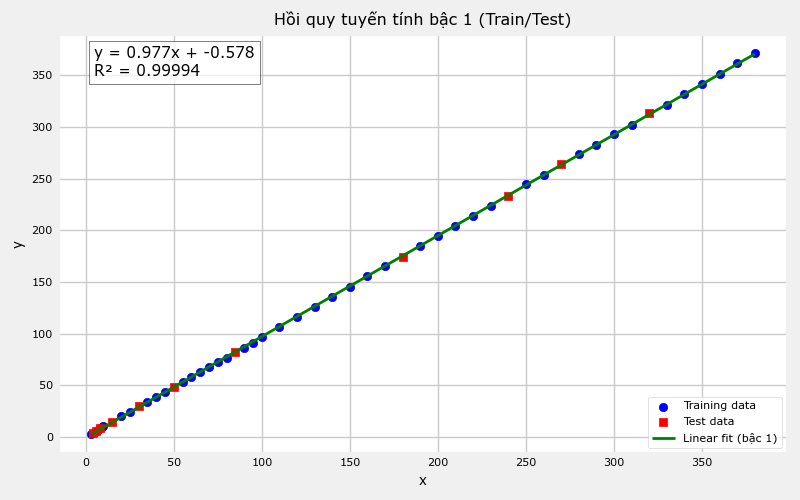

In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

x_test = x_te;
y_test = y_te;
x_train = x_tr;
y_train = y_tr;
# ===================== HUẤN LUYỆN =====================
model = LinearRegression()
model.fit(x_train.reshape(-1, 1), y_train)

a = model.coef_[0]
b = model.intercept_

# Dự đoán
y_pred_test = model.predict(x_test.reshape(-1, 1))

# ===================== ĐÁNH GIÁ =====================
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"Hàm hồi quy: y = {a:.5f}x + {b:.5f}")
print(f"MSE={mse:.6f} | MAE={mae:.6f} | R²={r2:.6f}")

# ===================== VẼ ĐỒ THỊ =====================
x_line = np.linspace(min(x_train.min(), x_test.min()), 
                     max(x_train.max(), x_test.max()), 300).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, color='blue', label='Training data')
plt.scatter(x_test, y_test, color='red', marker='s', label='Test data')
plt.plot(x_line, y_line, color='green', linewidth=2, label='Linear fit (bậc 1)')

# Hiển thị phương trình
eq_text = f"y = {a:.3f}x + {b:.3f}\nR² = {r2:.5f}"
plt.text(0.05, 0.9, eq_text, transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.7))

plt.title("Hồi quy tuyến tính bậc 1 (Train/Test)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()